# 05 · Calibración e interpretabilidad

**Objetivo.** (1) Asegurar que las probabilidades predichas son fiables (calibración), requisito para que el xG agregado sea interpretable; (2) explicar el modelo (importancia de variables / SHAP).

Un xG bien calibrado cumple que, entre los disparos con xG≈0.3, ~30 % acaban en gol. Medimos la calibración con la **curva de fiabilidad** y el **ECE**.

In [1]:
# Bootstrap: hace importable el paquete `xg` desde notebooks/ (src layout)
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if (pathlib.Path.cwd().name == 'notebooks') else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from xg import config, features, models, analysis, visualization
from xg import data as data_loader
from xg.models import evaluation, statistics
pd.set_option('display.float_format', lambda v: f'{v:0.4f}')
config.ensure_dirs()
np.random.seed(config.RANDOM_STATE)
print('Proyecto:', config.PROJECT_ROOT.name)

Proyecto: TFM_xG_MachineLearning


In [2]:
raw, source = data_loader.build_shots_dataframe(source='auto')
feat = features.engineer_features(raw)
X, y, comp = features.split_features_target(feat, drop_penalties=True, return_competition=True)
if config.HOLDOUT_COMPETITION in set(comp.dropna()):
    (Xtr,ytr),(Xv,yv),(Xte,yte),(Xtrv,ytrv) = evaluation.make_competition_holdout_splits(
        X, y, comp, config.HOLDOUT_COMPETITION
    )
else:
    (Xtr,ytr),(Xv,yv),(Xte,yte),(Xtrv,ytrv) = evaluation.make_splits(X, y)

## 5.1 Modelo sin calibrar vs calibrado (isotónica)

In [3]:
best_name = evaluation.evaluate_models_cv(
    {n: models.build_model_pipeline(n) for n in models.available_model_names()}, Xtrv, ytrv
).index[0]
uncal = models.build_model_pipeline(best_name).fit(Xtrv, ytrv)
cal = models.calibrate_pipeline(models.build_model_pipeline(best_name), method='isotonic', cv=config.CV_FOLDS).fit(Xtrv, ytrv)
# Guardado oficial de modelos: run_pipeline.py
p_unc = uncal.predict_proba(Xte)[:,1]; p_cal = cal.predict_proba(Xte)[:,1]
print('ECE sin calibrar:', round(evaluation.expected_calibration_error(yte.values, p_unc),4))
print('ECE calibrado   :', round(evaluation.expected_calibration_error(yte.values, p_cal),4))

ECE sin calibrar: 0.0206
ECE calibrado   : 0.0176


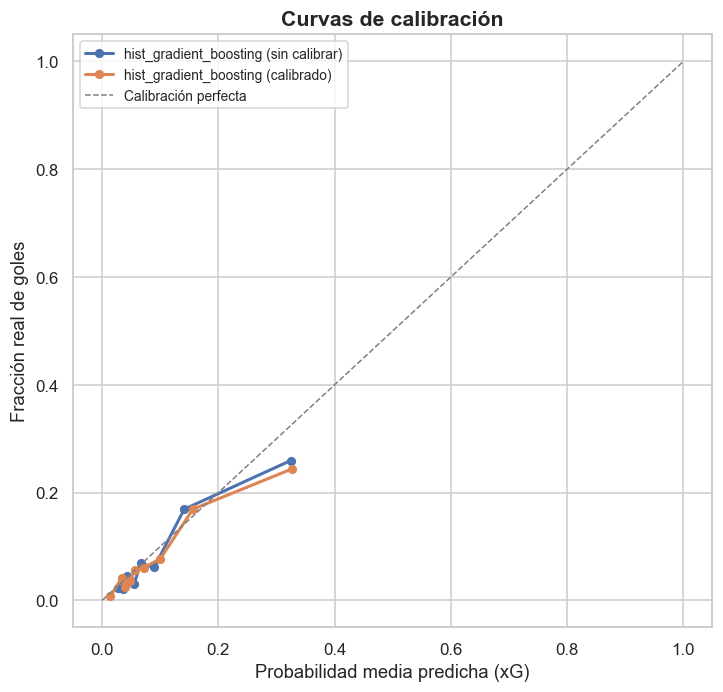

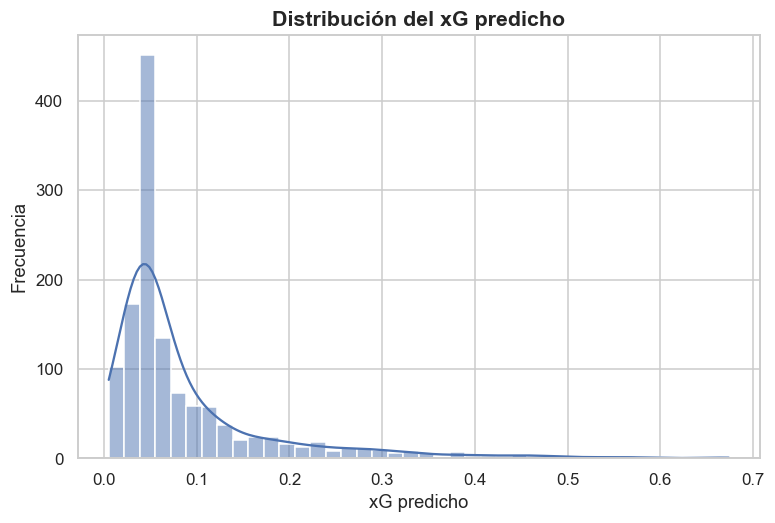

In [4]:
res = {f'{best_name} (sin calibrar)': (yte.values, p_unc),
       f'{best_name} (calibrado)': (yte.values, p_cal)}
visualization.plot_calibration_curves(res, save_as='calibration_curves'); plt.show()
visualization.plot_xg_distribution(p_cal, save_as='xg_distribution'); plt.show()

## 5.2 Validación contra el xG generador (solo modo sintético)
Si los datos son sintéticos, conocemos la probabilidad real (`true_xg`) y podemos medir el error absoluto medio de recuperación — una prueba fuerte de que el modelo aprende la física correcta.

In [5]:
if 'true_xg' in feat.columns:
    sub = feat[feat['is_penalty']==0].reset_index(drop=True)
    Xall,_ = features.split_features_target(feat, drop_penalties=True)
    sub['xg_pred'] = cal.predict_proba(Xall)[:,1]
    mae = np.mean(np.abs(sub['xg_pred'] - sub['true_xg']))
    print('MAE frente al xG generador (oráculo):', round(float(mae),4))
    plt.scatter(sub['true_xg'], sub['xg_pred'], s=8, alpha=0.3)
    plt.plot([0,1],[0,1],'r--'); plt.xlabel('xG real (generador)'); plt.ylabel('xG predicho')
    plt.title('Recuperación del xG verdadero'); plt.show()
else:
    print('Datos reales: no hay oráculo de xG verdadero.')

Datos reales: no hay oráculo de xG verdadero.


## 5.3 Interpretabilidad: importancia por permutación
Método agnóstico al modelo: mide la caída de rendimiento al permutar cada variable de entrada. Operamos sobre el `Pipeline` completo.

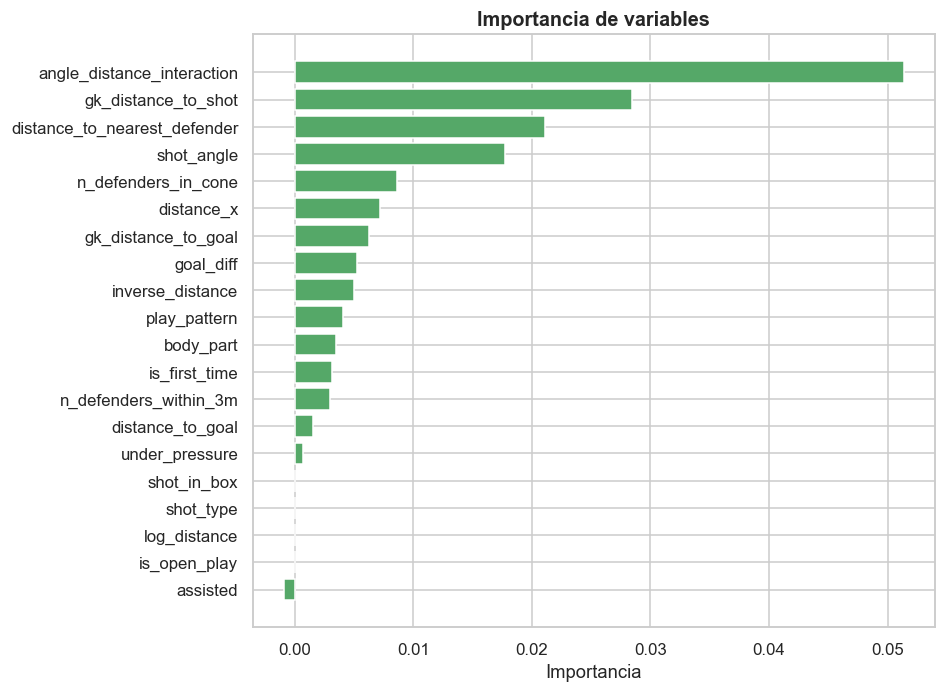

In [6]:
imp = analysis.permutation_feature_importance(uncal, Xte, yte, n_repeats=10)
# Guardado oficial de importancia: run_pipeline.py
visualization.plot_feature_importance(imp, save_as='feature_importance'); plt.show()
imp.head(10)

## 5.4 SHAP (opcional)
Si `shap` está instalado, se calcula la explicación local/global.

In [7]:
expl = analysis.shap_summary(uncal, Xte.sample(min(500,len(Xte)), random_state=config.RANDOM_STATE))
print('SHAP disponible:', expl is not None)
# import shap; shap.plots.beeswarm(expl)  # descomentar si shap está instalado

SHAP disponible: False


**Conclusión.** La calibración isotónica debe interpretarse con cautela: en el test por competición mejora ligeramente Brier, Log Loss y ECE, pero no constituye una mejora drástica ni universal. Las variables geométricas (distancia, ángulo y derivadas) siguen dominando la importancia, en línea con el conocimiento del dominio.
